# AMPK model development: Tests of model from Allen Lueng
#### Note: This model was translated from Copasi (mito_cyto.cps) to python 

Update as of 10/24/22 - **Something is incorrect! Trajectories are reading negative values!**
Check mito_cyto_allen_model.py, especially paying attention to the two functions for Michaelis-Menten
and OxPhos

In [1]:
import mito_cyto_allen_model as model
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib inline

In [3]:
# initial conditions
x = np.zeros(22)
x[0] = 2.12416e-13	 #metabolite 'ADP': reactions
x[1] = 1.8223e-12	 #metabolite 'ADP_m': reactions
x[2] = 1.00023e-16	 #metabolite 'p_AMPK': reactions
x[3] = 1.00005e-16	 #metabolite 'AMPK_m': reactions
x[4] = 9.63666e-16	 #metabolite 'AMPK': reactions
x[5] = 1.00005e-16	 #metabolite 'p_AMPK_m': reactions
x[6] = 9.98667e-16	 #metabolite 'AMP_AMPK': reactions
x[7] = 1.00002e-16	 #metabolite 'AMP_AMPK_m': reactions
x[8] = 1.49186e-17	 #metabolite 'ATP_p_AMPK': reactions
x[9] = 1.00007e-16	 #metabolite 'ATP_p_AMPK_m': reactions
x[10] = 1.00009e-17  #metabolite 'ADP_AMPK': reactions
x[11] = 9.99908e-16  #metabolite 'ADP_AMPK_m': reactions
x[12] = 1e-14  #metabolite 'AMP': reactions
x[13] = 1.00002e-16  #metabolite 'AMP_p_AMPK_m': reactions
x[14] = 1.0003e-17	#metabolite 'ADP_p_AMPK': reactions
x[15] = 1e-16  #metabolite 'ADP_p_AMPK_m': reactions
x[16] = 1e-15  #metabolite 'ATP_AMPK': reactions
x[17] = 2.50004e-12  #metabolite 'ATP_m': reactions
x[18] = 0 #metabolite 'ADP_lysosome': reactions
x[19] = 0  #metabolite 'AMP_lysosome': reactions
x[20] = 0  #metabolite 'ATP_lysosome': reactions
x[21] = 3e-12  #metabolite 'Pi': reactions

# parameters from Allen Lueng's Copasi model mito_cyto.cps
p = np.zeros(69)
p[0] = 1e-15	#metabolite 'glucose': fixed
p[1] = 1e-15	#metabolite 'pyruvate': fixed
p[2] = 1e-15	#metabolite 'pyruvate_m': fixed
p[3] = 1e-15	#compartment 'lysosome':fixed
p[4] = 1e-15	#compartment 'cytosol':fixed
p[5] = 1e-15	#compartment 'mitochondria':fixed
p[6] = 2e-11	#compartment 'mito_cyto':fixed
p[7] = 1	#global quantity 'n':fixed
p[8] = 450	#global quantity 'total_AMPK':fixed
p[9] = 1	#global quantity 'n1':fixed
p[10] = 300	#global quantity '_T_':fixed
p[11] = 3.14159	#global quantity '_PI_':fixed
p[12] = 96485.3	#global quantity '_F_':fixed
p[13] = 9.64853e-05	#global quantity '_F_nmol_':fixed
p[14] = 6.02214e+11	#global quantity '_N_pmol_':fixed
p[15] = 1e-09	#global quantity '_K_GHK_':fixed
p[16] = 8314.46	#global quantity '_R_':fixed
p[17] = 1000	#global quantity 'K_millivolts_per_volt':fixed
p[18] = 0	#global quantity 'Kr_rate_of_ATP_hydrolysis':fixed
p[19] = 0.000831589	#global quantity 'Kf_ATP_binding_AMPK':fixed
p[20] = 0.01	#global quantity 'Kr_ATP_binding_AMPK':fixed
p[21] = 0.00250488	#global quantity 'Kf_ADP_binding_AMPK':fixed
p[22] = 0.0001	#global quantity 'Kr_ADP_binding_AMPK':fixed
p[23] = 0.0001	#global quantity 'Kf_AMP_binding_AMPK':fixed
p[24] = 0.01	#global quantity 'Kr_AMP_binding_AMPK':fixed
p[25] = 0.000774664	#global quantity 'Kf_ATP_binding_pAMPK':fixed
p[26] = 0.000100331	#global quantity 'Kr_ATP_binding_pAMPK':fixed
p[27] = 0.00999998	#global quantity 'Kf_ADP_binding_pAMPK':fixed
p[28] = 0.000100004	#global quantity 'Kr_ADP_binding_pAMPK':fixed
p[29] = 0.000100059	#global quantity 'Kf_AMP_binding_pAMPK':fixed
p[30] = 0.000396674	#global quantity 'Kr_AMP_binding_pAMPK':fixed
p[31] = 1475.78	#global quantity 'Km_phosphorylation_of_AMPK':fixed
p[32] = 0.121172	#global quantity 'Vmax_phosphorylation_of_AMPK':fixed
p[33] = 111.473	#global quantity 'Km_dephosphorylation_of_AMPK':fixed
p[34] = 10.8709	#global quantity 'Vmax_dephosphorylation_of_AMPK':fixed
p[35] = 1053.26	#global quantity 'Km_phosphorylation_of_ATP_AMPK':fixed
p[36] = 0.162046	#global quantity 'Vmax_phosphorylation_of_ATP_AMPK':fixed
p[37] = 140.741	#global quantity 'Km_phosphorylation_of_AMP_AMPK':fixed
p[38] = 2.02627	#global quantity 'Vmax_phosphorylation_of_AMP_AMPK':fixed
p[39] = 215.351	#global quantity 'Km_phosphorylation_of_ADP_AMPK':fixed
p[40] = 0.697823	#global quantity 'Vmax_phosphorylation_of_ADP_AMPK':fixed
p[41] = 6.1571	#global quantity 'Km_dephosphorylation_of_ATP_p_AMPK':fixed
p[42] = 72.508	#global quantity 'Vmax_dephosphorylation_of_ATP_p_AMPK':fixed
p[43] = 17.48	#global quantity 'Km_dephosphorylation_of_ADP_p_AMPK':fixed
p[44] = 0.0358125	#global quantity 'Vmax_dephosphorylation_of_ADP_p_AMPK':fixed
p[45] = 6.36734	#global quantity 'Km_dephosphorylation_of_AMP_p_AMPK':fixed
p[46] = 0.146208	#global quantity 'Vmax_dephosphorylation_of_AMP_p_AMPK':fixed
p[47] = 0	#global quantity 'Kr_glycolysis':fixed
p[48] = 9.24309e-06	#global quantity 'XAK_simple_adenylate_kinase':fixed
p[49] = 0.536266	#global quantity 'KAK_simple_adenylate_kinase':fixed
p[50] = 58	#global quantity 'KADP_Oxidative_Phosphorylation':fixed
p[51] = 500	#global quantity 'Vmaxoxphos_Oxidative_Phosphorylation':fixed
p[52] = 2.568	#global quantity 'nH_Oxidative_Phosphorylation':fixed
p[53] = 1e-06	#global quantity 'Kf_ANT':fixed
p[54] = 1e-06	#global quantity 'Kr_ANT':fixed
p[55] = 1e-06	#global quantity 'Kf_pyruvate_transfer':fixed
p[56] = 1e-06	#global quantity 'Kr_pyruvate_transfer':fixed
p[57] = 0.1	#global quantity 'Kf_basal_ATP_production':fixed
p[58] = 0	#global quantity 'Kr_basal_ATP_production':fixed
p[59] = 1.5	#global quantity 'activity_scale':fixed
p[60] = 0.663742	#global quantity 'baseline_activity':fixed
p[61] = 0.1	#reaction 'simple adenylate kinase':  kinetic parameter 'k1'
p[62] = 0.1	#reaction 'simple adenylate kinase':  kinetic parameter 'k2'
p[63] = 0.1	#reaction 'simple adenylate kinase_copy':  kinetic parameter 'k1'
p[64] = 0.1	#reaction 'simple adenylate kinase_copy':  kinetic parameter 'k2'
p[65] = 1.7172224382999999e-15	#ct[0] conserved total for 'ATP_AMPK_m'
p[66] = 3.7367737269944892e-15	#ct[1] conserved total for 'AMP_p_AMPK'
p[67] = 9.2213347519424476e-12	#ct[2] conserved total for 'ATP'
p[68] = 4.4221399788238003e-12	#ct[3] conserved total for 'AMP_m'

tspan = (0, 25000)

In [4]:
# does the rhs run?
model.ampk_rhs(0, x, p)

array([ 9.40282761e-12, -6.14156957e-10, -9.19331413e-16, -6.39157409e-16,
       -7.20269676e-15, -2.02674277e-15, -9.95564809e-18,  8.22065431e-19,
        5.44734792e-16, -9.62193376e-16,  5.12731196e-16,  4.53365701e-16,
       -4.48791756e-12,  1.38936181e-19,  2.12475354e-16,  1.82539888e-15,
        6.86126342e-15,  3.07076960e-10,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00])

In [5]:
x_sol = solve_ivp(model.ampk_rhs, tspan, x, args=([p]), method='BDF')

Text(0, 0.5, 'All Mitochondrial AMPK')

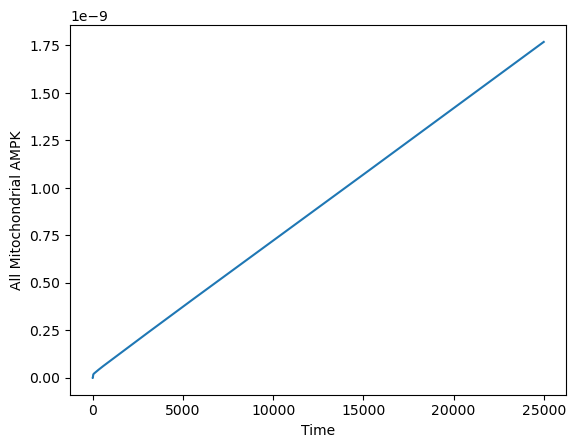

In [15]:
ATP_AMPK_m = p[65]-x_sol.y[3]-x_sol.y[5]-x_sol.y[7]-x_sol.y[9]-1*x_sol.y[11]-x_sol.y[13]-x_sol.y[15]
plt.plot(x_sol.t, x_sol.y[3]+x_sol.y[7]+x_sol.y[11]+ATP_AMPK_m) # AMPK_m + AMP_AMPK_m + ADP_AMPK_m + ATP_AMPK_m
plt.xlabel("Time")
plt.ylabel("All Mitochondrial AMPK")

#### The above plot looks problematic! Double check implementation and translation from Copasi!